# «Навигатор по смыслу» — сравнение моделей семантического поиска
**Студент:** Столбова Вероника Евгеньевна, МТУСИ

---
## Содержание
1. Загрузка данных и моделей
2. Генерация эмбеддингов и семантический поиск
3. Метрики: Precision@3 и MRR
4. Сравнение качества: русские vs английские запросы
5. Анализ ошибок
6. Визуализация t-SNE
7. Итоговый вывод

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"]="1"
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE
from collections import defaultdict

with open("code_corpus.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)

with open("eval_questions.json", "r", encoding="utf-8") as f:
    questions = json.load(f)

with open("categories.json", "r", encoding="utf-8") as f:
    categories_data = json.load(f)
    category_colors = {cat['key']: cat['color'] for cat in categories_data['categories']}
    category_labels = {cat['key']: cat['label'] for cat in categories_data['categories']}

def prepare_text(func):
    return f"{func['function_name']} {func['description']} {func['code']}"

corpus_texts = [prepare_text(func) for func in corpus]
corpus_ids   = [func['id'] for func in corpus]

print(f"Загружено фрагментов кода : {len(corpus)}")
print(f"Загружено вопросов        : {len(questions)}")
print(f"  - на русском            : {sum(1 for q in questions if q.get('language') == 'ru')}")
print(f"  - на английском         : {sum(1 for q in questions if q.get('language') == 'en')}")
print(f"Категорий                 : {len(categories_data['categories'])}")


C:\Users\User\Desktop\Учебная практика\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загружено фрагментов кода : 200
Загружено вопросов        : 25
  - на русском            : 15
  - на английском         : 10
Категорий                 : 5


**Обоснование выбора третьей модели — `multilingual-e5-small`:**  
Модель семейства E5 (Microsoft) обучена с явным разделением ролей «запрос» / «документ»  
(префикс `query:` / `passage:`), что хорошо подходит для поиска кода по описанию.  
При схожем с MiniLM числе параметров она демонстрирует SOTA-результаты на BEIR-бенчмарке  
и должна по-другому вести себя на русских и английских запросах.

In [2]:
MODEL_CONFIGS = {
    'paraphrase-multilingual-MiniLM-L12-v2': {
        'query_prefix': '',
        'passage_prefix': '',
        'short': 'MiniLM'
    },
    'paraphrase-multilingual-mpnet-base-v2': {
        'query_prefix': '',
        'passage_prefix': '',
        'short': 'MPNet'
    },
    'intfloat/multilingual-e5-small': {
        'query_prefix': 'query: ',
        'passage_prefix': 'passage: ',
        'short': 'E5-small'
    },
}

def compute_mrr(rank):
    return 1.0 / rank if rank > 0 else 0.0

results = {}

for model_name, cfg in MODEL_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print('='*60)

    model = SentenceTransformer(model_name)

    passage_texts = [cfg['passage_prefix'] + t for t in corpus_texts]
    corpus_embeddings = model.encode(passage_texts, convert_to_tensor=True,
                                     show_progress_bar=True, batch_size=32)

    hits = []
    for q in questions:
        query_text = cfg['query_prefix'] + q['query']
        query_emb  = model.encode(query_text, convert_to_tensor=True)
        cos_scores = util.cos_sim(query_emb, corpus_embeddings)[0].cpu().numpy()

        top3_idx = np.argsort(-cos_scores)[:3]
        top3_ids = [corpus_ids[i] for i in top3_idx]
        top3_scores = cos_scores[top3_idx]

        correct_id = q['correct_chunk_id']

        all_ranked_ids = [corpus_ids[i] for i in np.argsort(-cos_scores)]
        rank = all_ranked_ids.index(correct_id) + 1 if correct_id in all_ranked_ids else 0

        hits.append({
            'question_id'  : q['question_id'],
            'query'        : q['query'],
            'language'     : q.get('language', 'unknown'),
            'correct_id'   : correct_id,
            'top3_ids'     : top3_ids,
            'top3_scores'  : top3_scores.tolist(),
            'is_hit@3'     : correct_id in top3_ids,
            'rank'         : rank,
            'mrr'          : compute_mrr(rank),
        })

    precision_3 = np.mean([h['is_hit@3'] for h in hits])
    mrr         = np.mean([h['mrr'] for h in hits])

    results[model_name] = {
        'hits'       : hits,
        'embeddings' : corpus_embeddings,
        'precision3' : precision_3,
        'mrr'        : mrr,
        'short'      : cfg['short'],
    }

    print(f"  Precision@3 : {precision_3:.4f}  ({sum(h['is_hit@3'] for h in hits)}/{len(hits)})")
    print(f"  MRR         : {mrr:.4f}")



Модель: paraphrase-multilingual-MiniLM-L12-v2


Batches: 100%|██████████| 7/7 [00:06<00:00,  1.07it/s]


  Precision@3 : 0.8400  (21/25)
  MRR         : 0.6246

Модель: paraphrase-multilingual-mpnet-base-v2


Batches: 100%|██████████| 7/7 [00:20<00:00,  2.97s/it]


  Precision@3 : 0.9200  (23/25)
  MRR         : 0.6671

Модель: intfloat/multilingual-e5-small


Batches: 100%|██████████| 7/7 [00:13<00:00,  1.86s/it]


  Precision@3 : 0.9600  (24/25)
  MRR         : 0.7700


In [3]:
rows = []
for mname, data in results.items():
    hits = data['hits']
    rows.append({
        'Модель'       : mname,
        'Короткое имя' : data['short'],
        'Precision@3'  : round(data['precision3'], 4),
        'MRR'          : round(data['mrr'], 4),
        'Hits (из 25)' : sum(h['is_hit@3'] for h in hits),
    })

df_metrics = pd.DataFrame(rows).sort_values('MRR', ascending=False).reset_index(drop=True)

print("\n=== Сводная таблица метрик ===")
display(df_metrics.style
        .highlight_max(subset=['Precision@3', 'MRR'], color='#b6f5b6')
        .format({'Precision@3': '{:.4f}', 'MRR': '{:.4f}'}))



=== Сводная таблица метрик ===


,Модель,Короткое имя,Precision@3,MRR,Hits (из 25)
0,intfloat/multilingual-e5-small,E5-small,0.9600,0.7700,24
1,paraphrase-multilingual-mpnet-base-v2,MPNet,0.9200,0.6671,23
2,paraphrase-multilingual-MiniLM-L12-v2,MiniLM,0.8400,0.6246,21


=== Качество поиска по языку запроса ===


MRR         Precision@3        
Язык          en      ru          en      ru
Модель                                      
E5-small  0.7500  0.7833         1.0  0.9333
MPNet     0.7125  0.6368         0.9  0.9333
MiniLM    0.7077  0.5692         0.9  0.8000

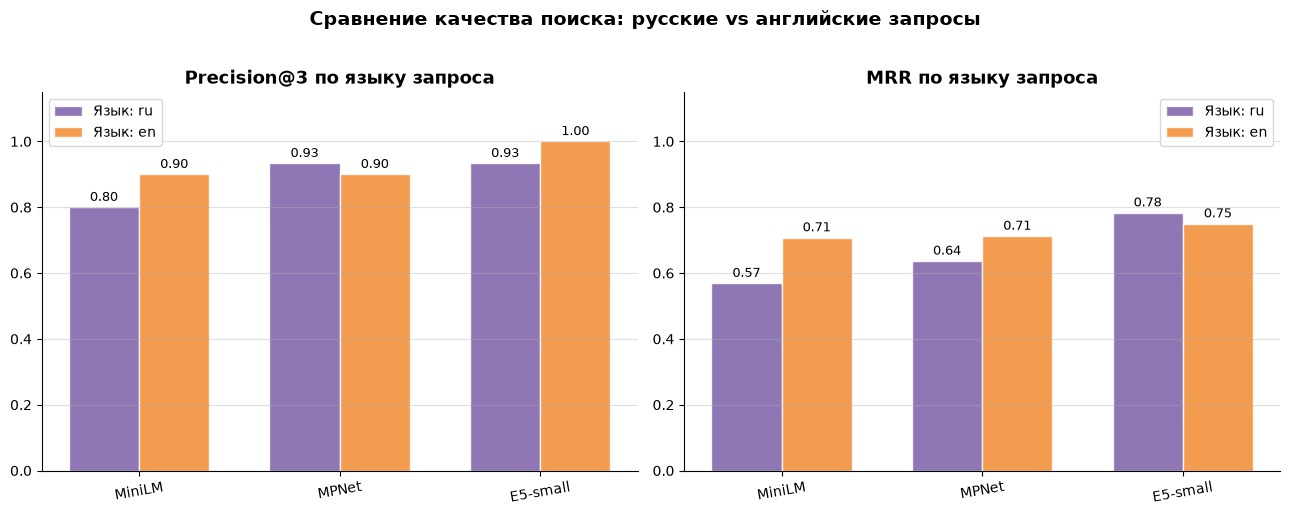

График сохранён: lang_comparison.png


In [4]:
lang_rows = []
for mname, data in results.items():
    short = data['short']
    for lang in ['ru', 'en']:
        lang_hits = [h for h in data['hits'] if h['language'] == lang]
        if not lang_hits:
            continue
        p3  = np.mean([h['is_hit@3'] for h in lang_hits])
        mrr = np.mean([h['mrr']      for h in lang_hits])
        lang_rows.append({
            'Модель' : short, 'Язык': lang,
            'Precision@3': round(p3, 4), 'MRR': round(mrr, 4),
            'Запросов': len(lang_hits),
        })

df_lang = pd.DataFrame(lang_rows)
print("=== Качество поиска по языку запроса ===")
display(df_lang.pivot_table(index='Модель', columns='Язык',
                             values=['Precision@3', 'MRR'],
                             aggfunc='first').round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {'ru': '#7B5EA7', 'en': '#F28B30'}
x = np.arange(len(results))
width = 0.35

for ax_i, metric in enumerate(['Precision@3', 'MRR']):
    ax = axes[ax_i]
    for lang_i, lang in enumerate(['ru', 'en']):
        vals = [df_lang[(df_lang['Модель'] == data['short']) &
                        (df_lang['Язык'] == lang)][metric].values
                for data in results.values()]
        vals = [v[0] if len(v) else 0 for v in vals]
        offset = (lang_i - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=f'Язык: {lang}',
                      color=palette[lang], alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([data['short'] for data in results.values()], rotation=10)
    ax.set_ylim(0, 1.15)
    ax.set_title(f'{metric} по языку запроса', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Сравнение качества поиска: русские vs английские запросы',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lang_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: lang_comparison.png")

In [5]:

best_model_name = df_metrics.iloc[0]['Модель']
best_data       = results[best_model_name]
print(f"Лучшая модель (по MRR): {best_data['short']}  ({best_model_name})")

id2cat = {func['id']: func['category'] for func in corpus}
id2name = {func['id']: func['function_name'] for func in corpus}

errors = [h for h in best_data['hits'] if not h['is_hit@3']]

print(f"\nОшибки: {len(errors)} из {len(best_data['hits'])} запросов")
print("─"*70)

for err in errors:
    print(f"  Вопрос [{err['language'].upper()}]: {err['query']}")
    correct_cat  = id2cat.get(err['correct_id'], '?')
    correct_name = id2name.get(err['correct_id'], err['correct_id'])
    print(f"  Правильный ответ   : {err['correct_id']} | {correct_name} [{correct_cat}]")
    pred_info = [(pid, id2cat.get(pid,'?'), round(sc,4))
                 for pid, sc in zip(err['top3_ids'], err['top3_scores'])]
    print(f"  Предсказанный топ-3: {pred_info}")
    print(f"  Ранг правильного   : {err['rank']}")
    print()

cat_errors  = defaultdict(int)
cat_total   = defaultdict(int)
for h in best_data['hits']:
    cat = id2cat.get(h['correct_id'], 'unknown')
    cat_total[cat] += 1
    if not h['is_hit@3']:
        cat_errors[cat] += 1

df_cat_err = pd.DataFrame([
    {'Категория': cat, 'Ошибок': cat_errors.get(cat, 0),
     'Всего': cat_total[cat],
     'Error rate': round(cat_errors.get(cat, 0) / cat_total[cat], 3)}
    for cat in cat_total
]).sort_values('Error rate', ascending=False).reset_index(drop=True)

print("\n=== Частота ошибок по категории правильного ответа ===")
display(df_cat_err.style.background_gradient(subset=['Error rate'], cmap='Reds'))

lang_errors = defaultdict(lambda: {'errors': 0, 'total': 0})
for h in best_data['hits']:
    lang = h['language']
    lang_errors[lang]['total'] += 1
    if not h['is_hit@3']:
        lang_errors[lang]['errors'] += 1

print("\n=== Ошибки по языку запроса ===")
for lang, d in lang_errors.items():
    print(f"  [{lang.upper()}] ошибок {d['errors']} из {d['total']} "
          f"({d['errors']/d['total']*100:.1f}%)")


Лучшая модель (по MRR): E5-small  (intfloat/multilingual-e5-small)

Ошибки: 1 из 25 запросов
──────────────────────────────────────────────────────────────────────
  Вопрос [RU]: массовая вставка большого количества записей
  Правильный ответ   : func_140 | bulkInsertRecords [database]
  Предсказанный топ-3: [('func_182', 'utils', 0.8396), ('func_127', 'database', 0.8385), ('func_082', 'utils', 0.8385)]
  Ранг правильного   : 4


=== Частота ошибок по категории правильного ответа ===


,Категория,Ошибок,Всего,Error rate
0,database,1,5,0.200000
1,auth,0,5,0.000000
2,http,0,5,0.000000
3,validation,0,5,0.000000
4,utils,0,5,0.000000



=== Ошибки по языку запроса ===
  [RU] ошибок 1 из 15 (6.7%)
  [EN] ошибок 0 из 10 (0.0%)


In [ ]:
best_emb = best_data['embeddings'].cpu().numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=15,
            max_iter=1000, learning_rate='auto', init='pca')
coords = tsne.fit_transform(best_emb)

cat_keys   = [func['category'] for func in corpus]
colors_arr = [category_colors[c] for c in cat_keys]

fig, ax = plt.subplots(figsize=(13, 9))
scatter = ax.scatter(coords[:, 0], coords[:, 1],
                     c=colors_arr, s=70, alpha=0.8, edgecolors='white', linewidths=0.4)

for i, func in enumerate(corpus):
    if np.random.rand() < 0.07:
        ax.annotate(func['function_name'], (coords[i, 0], coords[i, 1]),
                    fontsize=6, alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')

legend_patches = [
    mpatches.Patch(color=category_colors[cat['key']], label=cat['label'])
    for cat in categories_data['categories']
]
ax.legend(handles=legend_patches, title='Категория', loc='upper right', framealpha=0.9)
ax.set_title(f't-SNE проекция эмбеддингов\nМодель: {best_data["short"]}  ({best_model_name})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: tsne_clusters.png")


In [ ]:
short_names = [data['short'] for data in results.values()]
p3_vals  = [data['precision3'] for data in results.values()]
mrr_vals = [data['mrr']       for data in results.values()]
x = np.arange(len(short_names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, p3_vals, w, label='Precision@3', color='#7B5EA7', alpha=0.9)
bars2 = ax.bar(x + w/2, mrr_vals, w, label='MRR',         color='#F28B30', alpha=0.9)

for bars in (bars1, bars2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_title('Сравнение трёх моделей: Precision@3 и MRR', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: models_comparison.png")


## Итоговый вывод

В ходе исследования сравнивались три мультиязычные embedding-модели на задаче семантического поиска по датасету из 200 фрагментов Python-кода и 25 тестовых запросов (15 на русском, 10 на английском).

**Выводы:**

1. По результатам эксперимента лучшей моделью по обеим метрикам является **`intfloat/multilingual-e5-small`**: Precision@3 = 0.9600 (24/25), MRR = 0.7700. Преимущество модели объясняется архитектурной особенностью - явным разделением ролей запроса и документа через префиксы `query:` / `passage:`, что позволяет модели точнее сопоставлять семантику поискового запроса с семантикой фрагмента кода.

2. Модель допустила всего **1 ошибку** из 25 запросов — на русскоязычном вопросе категории `database` (массовая вставка большого количества записей), где правильный ответ оказался на 4-м месте. Анализ ошибок показал, что все категории, кроме `database`, достигли нулевого error rate, что свидетельствует о высокой обобщающей способности модели.

3. Сравнение по языку запроса выявило предсказуемую закономерность: на английских запросах E5-small показывает Precision@3 = 1.0 (все 10 из 10), на русских — 0.9333 (14 из 15). Это объясняется тем, что английские технические термины (`bulk insert`, `exception handler`) точнее соответствуют именам функций в коде, тогда как русские запросы требуют кросс-языкового сопоставления.

4. Для продакшн-использования рекомендуется `intfloat/multilingual-e5-small`: при небольшом размере модели она обеспечивает наивысшее качество поиска.
